<a href="https://colab.research.google.com/github/andreasangi/Prog-Machine-Learning/blob/resnet(OneClass_%26_IsolationForest)/provaprg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Rilevamento delle Anomalie con ResNet-50 e One-Class SVM

Poiché alleneremo il modello solo su immagini "buone", stiamo affrontando un problema di rilevamento delle anomalie. L'idea è di insegnare al modello a riconoscere le caratteristiche delle immagini normali. Quando una nuova immagine viene presentata, se le sue caratteristiche si discostano significativamente da quelle apprese, verrà classificata come difettosa (anomala).

Procederemo come segue:
1.  **Caricamento di ResNet-50 pre-addestrato:** Useremo un modello ResNet-50 pre-addestrato su ImageNet come base.
2.  **Estrazione delle caratteristiche:** Rimuoveremo lo strato di classificazione finale di ResNet-50 e useremo il resto del modello per estrarre vettori di caratteristiche ad alto livello dalle tue immagini "buone".
3.  **Addestramento di una One-Class SVM:** Addestreremo una One-Class SVM su questi vettori di caratteristiche. Questo modello imparerà il confine che racchiude le caratteristiche delle immagini "buone".
4.  **Previsione:** Per una nuova immagine, estrarrà le sue caratteristiche e la One-Class SVM determinerà se rientra nel "normale" o se è un'anomalia (difettosa).

In [2]:
# Installiamo le librerie necessarie se non già presenti
!pip install torch torchvision scikit-learn pillow

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import numpy as np
from PIL import Image
import os

# Configura il dispositivo (GPU se disponibile, altrimenti CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Caricamento e configurazione di ResNet-50 pre-addestrato

In [3]:
# Carica ResNet-50 pre-addestrato
resnet50 = models.resnet50(pretrained=True)

# Rimuovi l'ultimo strato di classificazione (fc) per usarlo come estrattore di caratteristiche
# Il modello ora produrrà il vettore di caratteristiche prima della classificazione finale
model = nn.Sequential(*list(resnet50.children())[:-1])

# Metti il modello in modalità valutazione e spostalo sul dispositivo
model.eval()
model.to(device)

print("ResNet-50 loaded and configured as feature extractor.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


ResNet-50 loaded and configured as feature extractor.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Preparazione del Dataset e Trasformazioni

Definisci le trasformazioni da applicare alle immagini e una classe `Dataset` personalizzata per caricare le tue immagini "buone".

In [5]:
# Definisci le trasformazioni per le immagini
transform = transforms.Compose([
    # Rimosso Resize e CenterCrop, dato che le immagini sono già con lo stesso formato
    transforms.ToTensor(),         # Converte l'immagine in un tensore PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizzazione ImageNet
])

# Dataset personalizzato per caricare immagini da una directory
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# --- SOSTITUISCI QUESTO PERCORSO CON IL PERCORSO DELLA TUA CARTELLA SU GOOGLE DRIVE ---
good_images_dir = '/content/drive/MyDrive/metal_nut/train/good'

# Crea il dataset e il DataLoader
good_dataset = CustomImageDataset(root_dir=good_images_dir, transform=transform)
good_dataloader = DataLoader(good_dataset, batch_size=32, shuffle=False)

print(f"Found {len(good_dataset)} good images in {good_images_dir}")

Found 220 good images in /content/drive/MyDrive/metal_nut/train/good


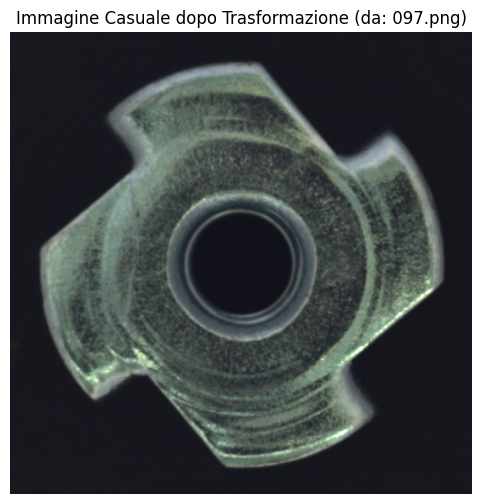

In [6]:
import matplotlib.pyplot as plt
import random
import numpy as np

# Scegli un indice casuale dal good_dataset
random_index = random.randint(0, len(good_dataset) - 1)

# Ottieni l'immagine trasformata (è già un tensore)
transformed_image_tensor = good_dataset[random_index]

# Denormalizza l'immagine per la visualizzazione
# I valori di mean e std sono quelli usati per la normalizzazione ImageNet
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Trasforma il tensore in un'immagine numpy, riordina gli assi e denormalizza
image_to_display = transformed_image_tensor.permute(1, 2, 0).cpu().numpy() # C, H, W -> H, W, C
image_to_display = std * image_to_display + mean # Denormalizzazione
image_to_display = np.clip(image_to_display, 0, 1) # Assicurati che i valori siano tra 0 e 1

# Mostra l'immagine
plt.figure(figsize=(6, 6))
plt.imshow(image_to_display)
plt.title(f"Immagine Casuale dopo Trasformazione (da: {good_dataset.image_files[random_index].split('/')[-1]})")
plt.axis('off')
plt.show()


### 3. Estrazione delle Caratteristiche

In [7]:
def extract_features(dataloader, model, device):
    features = []
    with torch.no_grad(): # Disabilita il calcolo del gradiente per l'inferenza
        for i, images in enumerate(dataloader):
            images = images.to(device)
            outputs = model(images) # Passa le immagini attraverso il modello
            outputs = outputs.squeeze() # Rimuovi le dimensioni singole (e.g., [batch_size, 2048, 1, 1] -> [batch_size, 2048])
            features.append(outputs.cpu().numpy()) # Sposta sul CPU e converti in NumPy
            if (i+1) % 10 == 0:
                print(f"Extracted features from {len(features) * dataloader.batch_size} images...")
    return np.vstack(features)

# Estrai le caratteristiche dalle immagini buone
print("Extracting features from good images...")
good_features = extract_features(good_dataloader, model, device)
print(f"Finished extracting features. Shape: {good_features.shape}")

Extracting features from good images...
Finished extracting features. Shape: (220, 2048)


### 4. Addestramento della One-Class SVM

Ora useremo le caratteristiche estratte per addestrare un modello One-Class SVM. È una buona pratica scalare le caratteristiche prima di addestrare la SVM.

In [8]:
# Scala le caratteristiche (importante per SVM)
scaler = StandardScaler()
good_features_scaled = scaler.fit_transform(good_features)

# Inizializza e addestra la One-Class SVM
# 'nu' è un parametro importante: una stima della frazione di outlier
# nel tuo set di addestramento (qui, ci aspettiamo 0, ma un piccolo valore
# può aiutare con il rumore o i falsi positivi).
# Un valore comune è 0.01 o 0.05. Kernel 'rbf' è spesso una buona scelta.
# Aumentiamo nu da 0.1 a 0.2 per rendere il modello meno stretto sul set di addestramento
svm_model = OneClassSVM(kernel='rbf', nu=0.1, gamma='auto')
svm_model.fit(good_features_scaled)

print("One-Class SVM trained successfully.")

One-Class SVM trained successfully.


### 5. Funzione di Previsione per nuove immagini

Ora puoi usare il modello addestrato per prevedere se una nuova immagine è "buona" o "difettosa".

In [9]:
def predict_anomaly(image_path, model, svm_model, scaler, transform, device):
    # Carica e trasforma l'immagine
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device) # Aggiungi una dimensione batch

    # Estrai le caratteristiche
    with torch.no_grad():
        features = model(image).squeeze().cpu().numpy().reshape(1, -1)

    # Scala le caratteristiche
    features_scaled = scaler.transform(features)

    # Prevedi con la One-Class SVM
    prediction = svm_model.predict(features_scaled)

    # -1 significa anomalia (difettosa), 1 significa normale (buona)
    if prediction == -1:
        return "Difettosa (Anomalia)"
    else:
        return "Buona (Normale)"

# --- Esempio di utilizzo: Sostituisci con il percorso di una TUA immagine ---
# Puoi usare un'immagine buona o una difettosa per testare.
# Per esempio, salva un'immagine di test come 'test_image.jpg' in /content/
example_image_path = '/content/test_image.jpg'

# Assicurati che l'immagine di test esista. Potrebbe essere necessario caricarla qui.
# Esempio: from google.colab import files
# files.upload() # Caricherà il file nella root di /content/

# Se non hai un'immagine di test, puoi creare una directory e copiarne una delle buone per vedere come viene classificata.
# os.makedirs('/content/test_images', exist_ok=True)
# Esempio: !cp /content/good_images/image_001.jpg /content/test_images/test_image.jpg

if os.path.exists(example_image_path):
    result = predict_anomaly(example_image_path, model, svm_model, scaler, transform, device)
    print(f"L'immagine '{example_image_path}' è stata classificata come: {result}")
else:
    print(f"ATTENZIONE: L'immagine di esempio '{example_image_path}' non trovata. Per favore, carica un'immagine di test per provare la previsione.")

ATTENZIONE: L'immagine di esempio '/content/test_image.jpg' non trovata. Per favore, carica un'immagine di test per provare la previsione.


### 6. Test del modello su immagini casuali da una directory di test

Questa sezione ti permetterà di selezionare un'immagine casuale da una sottocartella all'interno della tua directory di test e di valutarla con il modello addestrato.

In [10]:
import pandas as pd

# Dataset personalizzato per il set di test con etichette
class TestImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = [] # 0 per good, 1 per anomaly
        self.origin_subfolder = [] # Per tracciare la sottocartella di origine

        for subfolder_name in os.listdir(root_dir):
            subfolder_path = os.path.join(root_dir, subfolder_name)
            if os.path.isdir(subfolder_path):
                # 'good' subfolder contains normal images (label 0), others contain anomalies (label 1)
                is_anomaly = 1 if subfolder_name.lower() != 'good' else 0
                for f in os.listdir(subfolder_path):
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                        self.image_paths.append(os.path.join(subfolder_path, f))
                        self.labels.append(is_anomaly)
                        self.origin_subfolder.append(subfolder_name.lower())

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx], self.origin_subfolder[idx]

# --- SOSTITUISCI QUESTO PERCORSO CON IL PERCORSO DELLA TUA CARTELLA PRINCIPALE DI TEST SU GOOGLE DRIVE ---
test_images_base_dir = '/content/drive/MyDrive/metal_nut/test'

test_dataset = TestImageDataset(root_dir=test_images_base_dir, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Found {len(test_dataset)} images in test set.")

# Estrai le caratteristiche per il set di test
print("Extracting features from test images...")

all_features = []
all_true_labels = []
all_subfolders = []

with torch.no_grad():
    for images, labels, subfolders in test_dataloader:
        images = images.to(device)
        outputs = model(images).squeeze().cpu().numpy()
        all_features.append(outputs)
        all_true_labels.append(labels.numpy())
        all_subfolders.extend(subfolders) # Usa extend per aggiungere elementi singoli

all_features = np.vstack(all_features)
all_true_labels = np.hstack(all_true_labels)
print(f"Finished extracting features for test set. Shape: {all_features.shape}")

# Scala le caratteristiche di test usando lo scaler addestrato sul set 'good'
all_features_scaled = scaler.transform(all_features)

# Ottieni i punteggi di decisione dalla One-Class SVM
decision_scores = svm_model.decision_function(all_features_scaled)

# La One-Class SVM classifica come -1 (anomalia) o 1 (normale). Convertiamo in 1 (anomalia) o 0 (normale).
# Un punteggio inferiore a 0 per la decision_function corrisponde a una classificazione di -1.
# Per i nostri scopi, usiamo una soglia di 0 per decision_scores.
predicted_labels = (decision_scores < 0).astype(int) # 1 se anomalia, 0 se normale

print("\n--- Riepilogo delle Previsioni per Sottocartella ---")
# Raggruppa i risultati per sottocartella
results_df = pd.DataFrame({
    'subfolder': all_subfolders,
    'true_label': all_true_labels,
    'predicted_label': predicted_labels
})

for subfolder in results_df['subfolder'].unique():
    print(f"\nSottocartella: {subfolder.capitalize()}")
    sub_df = results_df[results_df['subfolder'] == subfolder]
    total_images = len(sub_df)
    predicted_good = (sub_df['predicted_label'] == 0).sum()
    predicted_defective = (sub_df['predicted_label'] == 1).sum()

    print(f"  Immagini totali: {total_images}")
    print(f"  Predette come Buone: {predicted_good}")
    print(f"  Predette come Difettose: {predicted_defective}")

    if subfolder == 'good':
        correctly_classified_good = (sub_df['true_label'] == 0) & (sub_df['predicted_label'] == 0)
        incorrectly_classified_defective = (sub_df['true_label'] == 0) & (sub_df['predicted_label'] == 1)
        print(f"  Correttamente classificate Buone: {correctly_classified_good.sum()}")
        print(f"  Classificate erroneamente come Difettose (Falsi Positivi): {incorrectly_classified_defective.sum()}")
    else:
        correctly_classified_defective = (sub_df['true_label'] == 1) & (sub_df['predicted_label'] == 1)
        incorrectly_classified_good = (sub_df['true_label'] == 1) & (sub_df['predicted_label'] == 0)
        print(f"  Correttamente classificate Difettose: {correctly_classified_defective.sum()}")
        print(f"  Classificate erroneamente come Buone (Falsi Negativi): {incorrectly_classified_good.sum()}")


Found 115 images in test set.
Extracting features from test images...
Finished extracting features for test set. Shape: (115, 2048)

--- Riepilogo delle Previsioni per Sottocartella ---

Sottocartella: Scratch
  Immagini totali: 23
  Predette come Buone: 1
  Predette come Difettose: 22
  Correttamente classificate Difettose: 22
  Classificate erroneamente come Buone (Falsi Negativi): 1

Sottocartella: Good
  Immagini totali: 22
  Predette come Buone: 8
  Predette come Difettose: 14
  Correttamente classificate Buone: 8
  Classificate erroneamente come Difettose (Falsi Positivi): 14

Sottocartella: Bent
  Immagini totali: 25
  Predette come Buone: 4
  Predette come Difettose: 21
  Correttamente classificate Difettose: 21
  Classificate erroneamente come Buone (Falsi Negativi): 4

Sottocartella: Flip
  Immagini totali: 23
  Predette come Buone: 0
  Predette come Difettose: 23
  Correttamente classificate Difettose: 23
  Classificate erroneamente come Buone (Falsi Negativi): 0

Sottocarte

### 8. Implementazione e Valutazione con Isolation Forest

Useremo l'algoritmo Isolation Forest come alternativa alla One-Class SVM per confrontare le prestazioni.

In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix
import pandas as pd

print("Addestramento e valutazione con Isolation Forest...")

# Inizializza l'Isolation Forest
# contamination: La proporzione di outlier nei dati (simile a nu nella OCSVM).
# Se non specificato, il valore predefinito è 'auto'. Un valore più alto può portare a più anomalie rilevate.
# Utilizzeremo un valore simile a quello di 'nu' per un confronto significativo.
isolation_forest_model = IsolationForest(contamination=0.2, random_state=42)

# Addestra il modello sulle caratteristiche scalate delle immagini 'buone'
# Isolation Forest è un modello non supervisionato, quindi non ha bisogno di etichette di training.
isolation_forest_model.fit(good_features_scaled)

# Effettua previsioni sul set di test
# predict() restituisce -1 per gli outlier (anomalie) e 1 per gli inlier (normali)
isolation_forest_predictions = isolation_forest_model.predict(all_features_scaled)

# Converti le previsioni per essere coerenti: 1 per anomalia, 0 per normale
# Le previsioni di Isolation Forest sono -1 (anomalia) e 1 (normale). Per la nostra metrica vogliamo 1 (anomalia) e 0 (normale).
# Quindi, dove è -1 diventa 1, dove è 1 diventa 0.
predicted_labels_if = np.where(isolation_forest_predictions == -1, 1, 0)

# Calcola la matrice di confusione
tn_if, fp_if, fn_if, tp_if = confusion_matrix(all_true_labels, predicted_labels_if).ravel()

print("\n--- Risultati Isolation Forest sul Test Set ---")
print(f"True Positives (Difettose correttamente classificate): {tp_if}")
print(f"False Positives (Buone classificate come difettose): {fp_if}")
print(f"False Negatives (Difettose classificate come buone): {fn_if}")
print(f"True Negatives (Buone correttamente classificate): {tn_if}")

# Riepilogo per sottocartella
results_df_if = pd.DataFrame({
    'subfolder': all_subfolders,
    'true_label': all_true_labels,
    'predicted_label_if': predicted_labels_if
})

print("\n--- Riepilogo delle Previsioni per Sottocartella (Isolation Forest) ---")
for subfolder in results_df_if['subfolder'].unique():
    print(f"\nSottocartella: {subfolder.capitalize()}")
    sub_df_if = results_df_if[results_df_if['subfolder'] == subfolder]
    total_images = len(sub_df_if)
    predicted_good = (sub_df_if['predicted_label_if'] == 0).sum()
    predicted_defective = (sub_df_if['predicted_label_if'] == 1).sum()

    print(f"  Immagini totali: {total_images}")
    print(f"  Predette come Buone: {predicted_good}")
    print(f"  Predette come Difettose: {predicted_defective}")

    if subfolder == 'good':
        correctly_classified_good = (sub_df_if['true_label'] == 0) & (sub_df_if['predicted_label_if'] == 0)
        incorrectly_classified_defective = (sub_df_if['true_label'] == 0) & (sub_df_if['predicted_label_if'] == 1)
        print(f"  Correttamente classificate Buone: {correctly_classified_good.sum()}")
        print(f"  Classificate erroneamente come Difettose (Falsi Positivi): {incorrectly_classified_defective.sum()}")
    else:
        correctly_classified_defective = (sub_df_if['true_label'] == 1) & (sub_df_if['predicted_label_if'] == 1)
        incorrectly_classified_good = (sub_df_if['true_label'] == 1) & (sub_df_if['predicted_label_if'] == 0)
        print(f"  Correttamente classificate Difettose: {correctly_classified_defective.sum()}")
        print(f"  Classificate erroneamente come Buone (Falsi Negativi): {incorrectly_classified_good.sum()}")


Addestramento e valutazione con Isolation Forest...

--- Risultati Isolation Forest sul Test Set ---
True Positives (Difettose correttamente classificate): 77
False Positives (Buone classificate come difettose): 12
False Negatives (Difettose classificate come buone): 16
True Negatives (Buone correttamente classificate): 10

--- Riepilogo delle Previsioni per Sottocartella (Isolation Forest) ---

Sottocartella: Scratch
  Immagini totali: 23
  Predette come Buone: 5
  Predette come Difettose: 18
  Correttamente classificate Difettose: 18
  Classificate erroneamente come Buone (Falsi Negativi): 5

Sottocartella: Good
  Immagini totali: 22
  Predette come Buone: 10
  Predette come Difettose: 12
  Correttamente classificate Buone: 10
  Classificate erroneamente come Difettose (Falsi Positivi): 12

Sottocartella: Bent
  Immagini totali: 25
  Predette come Buone: 5
  Predette come Difettose: 20
  Correttamente classificate Difettose: 20
  Classificate erroneamente come Buone (Falsi Negativi):

### 9. Ottimizzazione del parametro `contamination` per Isolation Forest

Ora eseguiamo un test su diversi valori del parametro `contamination` per l'algoritmo Isolation Forest e confrontiamo le prestazioni sul set di test.

In [12]:
contamination_values = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
results_if_tuning = []

print("Avvio l'ottimizzazione del parametro 'contamination' per Isolation Forest...")

for cont_val in contamination_values:
    print(f"Testing contamination={cont_val}")
    isolation_forest_model_tuned = IsolationForest(contamination=cont_val, random_state=42)
    isolation_forest_model_tuned.fit(good_features_scaled)

    # Effettua previsioni sul set di test
    predictions = isolation_forest_model_tuned.predict(all_features_scaled)
    predicted_labels_if_tuned = np.where(predictions == -1, 1, 0)

    # Calcola la matrice di confusione
    tn, fp, fn, tp = confusion_matrix(all_true_labels, predicted_labels_if_tuned).ravel()

    results_if_tuning.append({
        'contamination': cont_val,
        'True Positives': tp,
        'False Positives': fp,
        'False Negatives': fn,
        'True Negatives': tn
    })

results_df_tuning_if = pd.DataFrame(results_if_tuning)

print("\n--- Risultati Ottimizzazione Contamination (Isolation Forest) ---")
display(results_df_tuning_if)

print("\nAnalizza questi risultati per trovare il valore di 'contamination' che offre il miglior compromesso tra True Positives e False Positives/Negatives per le tue esigenze.")

Avvio l'ottimizzazione del parametro 'contamination' per Isolation Forest...
Testing contamination=0.01
Testing contamination=0.05
Testing contamination=0.1
Testing contamination=0.15
Testing contamination=0.2
Testing contamination=0.25
Testing contamination=0.3

--- Risultati Ottimizzazione Contamination (Isolation Forest) ---


,contamination,True Positives,False Positives,False Negatives,True Negatives
0,0.01,23,0,70,22
1,0.05,43,3,50,19
2,0.10,53,6,40,16
3,0.15,61,8,32,14
4,0.20,77,12,16,10
5,0.25,78,15,15,7
6,0.30,78,16,15,6



Analizza questi risultati per trovare il valore di 'contamination' che offre il miglior compromesso tra True Positives e False Positives/Negatives per le tue esigenze.


In [25]:
from sklearn.metrics import f1_score

# Calcola l'F1-score per la One-Class SVM (senza fine-tuning)
f1_svm_pre_fine_tune = f1_score(all_true_labels, predicted_labels, pos_label=1)
print(f"F1-score per One-Class SVM (ResNet-50 Base): {f1_svm_pre_fine_tune:.4f}")

# Calcola l'F1-score per l'Isolation Forest (senza fine-tuning)
f1_if_pre_fine_tune = f1_score(all_true_labels, predicted_labels_if, pos_label=1)
print(f"F1-score per Isolation Forest (ResNet-50 Base): {f1_if_pre_fine_tune:.4f}")

F1-score per One-Class SVM (ResNet-50 Base): 0.8737
F1-score per Isolation Forest (ResNet-50 Base): 0.8462


### 10. Fine-tuning di ResNet-50 per un'estrazione delle caratteristiche più specifica

In [14]:
import torch.optim as optim

# Carica un nuovo ResNet-50 pre-addestrato per il fine-tuning
fine_tune_resnet50 = models.resnet50(pretrained=True)

# Sostituisci l'ultimo strato (fully connected) con uno strato lineare che
# produce una singola uscita, ad esempio per una "dummy classification" sui dati buoni.
# La dimensione dell'input deve corrispondere all'output del penultimo strato di ResNet-50 (2048 per ResNet-50)
num_ftrs = fine_tune_resnet50.fc.in_features
fine_tune_resnet50.fc = nn.Linear(num_ftrs, 1) # Output a single logit

fine_tune_resnet50 = fine_tune_resnet50.to(device);

# Fase 1: Congela tutti i parametri tranne lo strato finale appena aggiunto
for param in fine_tune_resnet50.parameters():
    param.requires_grad = False

for param in fine_tune_resnet50.fc.parameters():
    param.requires_grad = True

# Definisci ottimizzatore e funzione di perdita per il fine-tuning
# Usiamo BCEWithLogitsLoss perché abbiamo un output lineare singolo e lo trattiamo come un problema binario
# dove tutte le immagini 'buone' sono classe 1.
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(fine_tune_resnet50.fc.parameters(), lr=0.001)

print("Modello ResNet-50 preparato per il fine-tuning della testa di classificazione.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Modello ResNet-50 preparato per il fine-tuning della testa di classificazione.


In [15]:
# Carica ResNet-50 pre-addestrato
resnet50 = models.resnet50(pretrained=True)

# Rimuovi l'ultimo strato di classificazione (fc) per usarlo come estrattore di caratteristiche
# Il modello ora produrrà il vettore di caratteristiche prima della classificazione finale
model = nn.Sequential(*list(resnet50.children())[:-1])

# Metti il modello in modalità valutazione e spostalo sul dispositivo
model.eval()
model.to(device)

print("ResNet-50 loaded and configured as feature extractor.")

ResNet-50 loaded and configured as feature extractor.


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Fase di addestramento 1: Addestramento della testa di classificazione

In [17]:
num_epochs_phase1 = 5 # Addestra per poche epoche

print(f"Avvio fase di addestramento 1 ({num_epochs_phase1} epoche) - Solo testa di classificazione...")
for epoch in range(num_epochs_phase1):
    fine_tune_resnet50.train() # Imposta il modello in modalità train
    running_loss = 0.0
    for inputs in good_dataloader:
        inputs = inputs.to(device)
        labels = torch.ones(inputs.size(0), 1).to(device) # Tutte le immagini 'buone' sono target 1

        optimizer.zero_grad()

        outputs = fine_tune_resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(good_dataset)
    print(f"Epoca {epoch+1}/{num_epochs_phase1}, Perdita: {epoch_loss:.4f}")

print("Fase di addestramento 1 completata.")

Avvio fase di addestramento 1 (5 epoche) - Solo testa di classificazione...
Epoca 1/5, Perdita: 0.1663
Epoca 2/5, Perdita: 0.0024
Epoca 3/5, Perdita: 0.0004
Epoca 4/5, Perdita: 0.0001
Epoca 5/5, Perdita: 0.0001
Fase di addestramento 1 completata.


#### Fase di addestramento 2: Sblocco e fine-tuning degli strati successivi

In [18]:
# Sblocca gli strati successivi di ResNet-50 (ad esempio, layer3 e layer4)
for name, param in fine_tune_resnet50.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False # Assicurati che i primi strati rimangano congelati

# Definisci un nuovo ottimizzatore con un learning rate inferiore per il fine-tuning completo
optimizer = optim.Adam(filter(lambda p: p.requires_grad, fine_tune_resnet50.parameters()), lr=0.0001)

num_epochs_phase2 = 5 # Aumenta se necessario

print(f"\nAvvio fase di addestramento 2 ({num_epochs_phase2} epoche) - Fine-tuning completo...")
for epoch in range(num_epochs_phase2):
    fine_tune_resnet50.train()
    running_loss = 0.0
    for inputs in good_dataloader:
        inputs = inputs.to(device)
        labels = torch.ones(inputs.size(0), 1).to(device)

        optimizer.zero_grad()

        outputs = fine_tune_resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(good_dataset)
    print(f"Epoca {epoch+1}/{num_epochs_phase2}, Perdita: {epoch_loss:.4f}")

print("Fase di addestramento 2 completata.")

# Rimuovi lo strato di classificazione finale per usare il modello come estrattore di caratteristiche
fine_tuned_feature_extractor = nn.Sequential(*list(fine_tune_resnet50.children())[:-1])
fine_tuned_feature_extractor.eval() # Imposta in modalità valutazione
fine_tuned_feature_extractor.to(device)

print("Modello ResNet-50 fine-tuned configurato come estrattore di caratteristiche.")


Avvio fase di addestramento 2 (5 epoche) - Fine-tuning completo...
Epoca 1/5, Perdita: 0.0000
Epoca 2/5, Perdita: 0.0000
Epoca 3/5, Perdita: 0.0000
Epoca 4/5, Perdita: 0.0000
Epoca 5/5, Perdita: 0.0000
Fase di addestramento 2 completata.
Modello ResNet-50 fine-tuned configurato come estrattore di caratteristiche.


### 11. Estrazione delle Caratteristiche con il modello ResNet-50 Fine-tuned

In [19]:
# Estrai le caratteristiche dalle immagini buone usando il nuovo estrattore fine-tuned
print("Extracting features from good images using fine-tuned ResNet-50...")
fine_tuned_good_features = extract_features(good_dataloader, fine_tuned_feature_extractor, device)
print(f"Finished extracting good features with fine-tuned model. Shape: {fine_tuned_good_features.shape}")

# Scala le nuove caratteristiche (importante per SVM e Isolation Forest)
fine_tuned_scaler = StandardScaler()
fine_tuned_good_features_scaled = fine_tuned_scaler.fit_transform(fine_tuned_good_features)
print("Fine-tuned good features scaled.")

# Estrai le caratteristiche per il set di test usando il nuovo estrattore fine-tuned
print("Extracting features from test images using fine-tuned ResNet-50...")

# Creiamo un dataloader senza shuffle per il set di test, assicurandoci l'ordine dei dati
test_dataloader_no_shuffle = DataLoader(test_dataset, batch_size=32, shuffle=False)

fine_tuned_all_features = []
fine_tuned_all_true_labels = []
fine_tuned_all_subfolders = []

with torch.no_grad():
    for images, labels, subfolders in test_dataloader_no_shuffle:
        images = images.to(device)
        outputs = fine_tuned_feature_extractor(images).squeeze().cpu().numpy()
        fine_tuned_all_features.append(outputs)
        fine_tuned_all_true_labels.append(labels.numpy())
        fine_tuned_all_subfolders.extend(subfolders) # Usa extend per aggiungere elementi singoli

fine_tuned_all_features = np.vstack(fine_tuned_all_features)
fine_tuned_all_true_labels = np.hstack(fine_tuned_all_true_labels)
print(f"Finished extracting test features with fine-tuned model. Shape: {fine_tuned_all_features.shape}")

# Scala le caratteristiche di test usando lo scaler addestrato sul set 'good' fine-tuned
fine_tuned_all_features_scaled = fine_tuned_scaler.transform(fine_tuned_all_features)
print("Fine-tuned test features scaled.")

Extracting features from good images using fine-tuned ResNet-50...
Finished extracting good features with fine-tuned model. Shape: (220, 2048)
Fine-tuned good features scaled.
Extracting features from test images using fine-tuned ResNet-50...
Finished extracting test features with fine-tuned model. Shape: (115, 2048)
Fine-tuned test features scaled.


### 12. Re-addestramento e Valutazione della One-Class SVM con le nuove caratteristiche

In [80]:
# Inizializza e addestra la One-Class SVM con le caratteristiche fine-tuned
print("Re-training One-Class SVM with fine-tuned features...")
svm_model_fine_tuned = OneClassSVM(kernel='rbf', nu=0.25, gamma='auto') # Puoi riutilizzare il nu o tunarlo di nuovo
svm_model_fine_tuned.fit(fine_tuned_good_features_scaled)
print("One-Class SVM re-trained successfully with fine-tuned features.")

# Ottieni i punteggi di decisione dalla One-Class SVM fine-tuned sul set di test
decision_scores_fine_tuned_svm = svm_model_fine_tuned.decision_function(fine_tuned_all_features_scaled)

# Converti le previsioni per essere coerenti: 1 per anomalia, 0 per normale
predicted_labels_fine_tuned_svm = (decision_scores_fine_tuned_svm < 0).astype(int) # 1 se anomalia, 0 se normale

print("\n--- Risultati One-Class SVM (Fine-tuned ResNet-50) sul Test Set ---")

# Riepilogo per sottocartella
results_df_fine_tuned_svm = pd.DataFrame({
    'subfolder': fine_tuned_all_subfolders,
    'true_label': fine_tuned_all_true_labels,
    'predicted_label': predicted_labels_fine_tuned_svm
})

for subfolder in results_df_fine_tuned_svm['subfolder'].unique():
    print(f"\nSottocartella: {subfolder.capitalize()}")
    sub_df_svm = results_df_fine_tuned_svm[results_df_fine_tuned_svm['subfolder'] == subfolder]
    total_images = len(sub_df_svm)
    predicted_good = (sub_df_svm['predicted_label'] == 0).sum()
    predicted_defective = (sub_df_svm['predicted_label'] == 1).sum()

    print(f"  Immagini totali: {total_images}")
    print(f"  Predette come Buone: {predicted_good}")
    print(f"  Predette come Difettose: {predicted_defective}")

    if subfolder == 'good':
        correctly_classified_good = (sub_df_svm['true_label'] == 0) & (sub_df_svm['predicted_label'] == 0)
        incorrectly_classified_defective = (sub_df_svm['true_label'] == 0) & (sub_df_svm['predicted_label'] == 1)
        print(f"  Correttamente classificate Buone: {correctly_classified_good.sum()}")
        print(f"  Classificate erroneamente come Difettose (Falsi Positivi): {incorrectly_classified_defective.sum()}")
    else:
        correctly_classified_defective = (sub_df_svm['true_label'] == 1) & (sub_df_svm['predicted_label'] == 1)
        incorrectly_classified_good = (sub_df_svm['true_label'] == 1) & (sub_df_svm['predicted_label'] == 0)
        print(f"  Correttamente classificate Difettose: {correctly_classified_defective.sum()}")
        print(f"  Classificate erroneamente come Buone (Falsi Negativi): {incorrectly_classified_good.sum()}")

Re-training One-Class SVM with fine-tuned features...
One-Class SVM re-trained successfully with fine-tuned features.

--- Risultati One-Class SVM (Fine-tuned ResNet-50) sul Test Set ---

Sottocartella: Scratch
  Immagini totali: 23
  Predette come Buone: 1
  Predette come Difettose: 22
  Correttamente classificate Difettose: 22
  Classificate erroneamente come Buone (Falsi Negativi): 1

Sottocartella: Good
  Immagini totali: 22
  Predette come Buone: 9
  Predette come Difettose: 13
  Correttamente classificate Buone: 9
  Classificate erroneamente come Difettose (Falsi Positivi): 13

Sottocartella: Bent
  Immagini totali: 25
  Predette come Buone: 1
  Predette come Difettose: 24
  Correttamente classificate Difettose: 24
  Classificate erroneamente come Buone (Falsi Negativi): 1

Sottocartella: Flip
  Immagini totali: 23
  Predette come Buone: 0
  Predette come Difettose: 23
  Correttamente classificate Difettose: 23
  Classificate erroneamente come Buone (Falsi Negativi): 0

Sottocart

### 13. Re-addestramento e Valutazione dell'Isolation Forest con le nuove caratteristiche

In [66]:
print("Re-training and evaluating Isolation Forest with fine-tuned features...")

# Inizializza l'Isolation Forest (puoi riutilizzare il contamination o tunarlo di nuovo)
isolation_forest_model_fine_tuned = IsolationForest(contamination=0.3, random_state=42)

# Addestra il modello sulle caratteristiche scalate delle immagini 'buone' fine-tuned
isolation_forest_model_fine_tuned.fit(fine_tuned_good_features_scaled)

# Effettua previsioni sul set di test con le caratteristiche fine-tuned
isolation_forest_predictions_fine_tuned = isolation_forest_model_fine_tuned.predict(fine_tuned_all_features_scaled)

# Converti le previsioni per essere coerenti: 1 per anomalia, 0 per normale
predicted_labels_fine_tuned_if = np.where(isolation_forest_predictions_fine_tuned == -1, 1, 0)

print("\n--- Risultati Isolation Forest (Fine-tuned ResNet-50) sul Test Set ---")

# Riepilogo per sottocartella
results_df_fine_tuned_if = pd.DataFrame({
    'subfolder': fine_tuned_all_subfolders,
    'true_label': fine_tuned_all_true_labels,
    'predicted_label_if': predicted_labels_fine_tuned_if
})

for subfolder in results_df_fine_tuned_if['subfolder'].unique():
    print(f"\nSottocartella: {subfolder.capitalize()}")
    sub_df_if = results_df_fine_tuned_if[results_df_fine_tuned_if['subfolder'] == subfolder]
    total_images = len(sub_df_if)
    predicted_good = (sub_df_if['predicted_label_if'] == 0).sum()
    predicted_defective = (sub_df_if['predicted_label_if'] == 1).sum()

    print(f"  Immagini totali: {total_images}")
    print(f"  Predette come Buone: {predicted_good}")
    print(f"  Predette come Difettose: {predicted_defective}")

    if subfolder == 'good':
        correctly_classified_good = (sub_df_if['true_label'] == 0) & (sub_df_if['predicted_label_if'] == 0)
        incorrectly_classified_defective = (sub_df_if['true_label'] == 0) & (sub_df_if['predicted_label_if'] == 1)
        print(f"  Correttamente classificate Buone: {correctly_classified_good.sum()}")
        print(f"  Classificate erroneamente come Difettose (Falsi Positivi): {incorrectly_classified_defective.sum()}")
    else:
        correctly_classified_defective = (sub_df_if['true_label'] == 1) & (sub_df_if['predicted_label_if'] == 1)
        incorrectly_classified_good = (sub_df_if['true_label'] == 1) & (sub_df_if['predicted_label_if'] == 0)
        print(f"  Correttamente classificate Difettose: {correctly_classified_defective.sum()}")
        print(f"  Classificate erroneamente come Buone (Falsi Negativi): {incorrectly_classified_good.sum()}")

Re-training and evaluating Isolation Forest with fine-tuned features...

--- Risultati Isolation Forest (Fine-tuned ResNet-50) sul Test Set ---

Sottocartella: Scratch
  Immagini totali: 23
  Predette come Buone: 3
  Predette come Difettose: 20
  Correttamente classificate Difettose: 20
  Classificate erroneamente come Buone (Falsi Negativi): 3

Sottocartella: Good
  Immagini totali: 22
  Predette come Buone: 10
  Predette come Difettose: 12
  Correttamente classificate Buone: 10
  Classificate erroneamente come Difettose (Falsi Positivi): 12

Sottocartella: Bent
  Immagini totali: 25
  Predette come Buone: 5
  Predette come Difettose: 20
  Correttamente classificate Difettose: 20
  Classificate erroneamente come Buone (Falsi Negativi): 5

Sottocartella: Flip
  Immagini totali: 23
  Predette come Buone: 0
  Predette come Difettose: 23
  Correttamente classificate Difettose: 23
  Classificate erroneamente come Buone (Falsi Negativi): 0

Sottocartella: Color
  Immagini totali: 22
  Prede

In [81]:
from sklearn.metrics import f1_score

# Calcola l'F1-score per la One-Class SVM (con ResNet-50 fine-tuned)
# Si noti che F1-score è calcolato per la classe positiva (anomalia = 1)
f1_svm = f1_score(fine_tuned_all_true_labels, predicted_labels_fine_tuned_svm, pos_label=1)
print(f"F1-score per One-Class SVM (ResNet-50 Fine-tuned): {f1_svm:.4f}")

# Calcola l'F1-score per l'Isolation Forest (con ResNet-50 fine-tuned)
f1_if = f1_score(fine_tuned_all_true_labels, predicted_labels_fine_tuned_if, pos_label=1)
print(f"F1-score per Isolation Forest (ResNet-50 Fine-tuned): {f1_if:.4f}")

F1-score per One-Class SVM (ResNet-50 Fine-tuned): 0.8842
F1-score per Isolation Forest (ResNet-50 Fine-tuned): 0.8398
